In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import dask
from dask.distributed import Client, LocalCluster

dask.config.set({"distributed.dashboard.link": "/proxy/{port}/status"})
cluster = LocalCluster(n_workers=64, threads_per_worker = 1)
client = Client(cluster)

# ---------------- config ----------------
BASE = Path("../data")

PATH_WBT  = BASE / "DailyMax-WBT"
PATH_HI   = BASE / "hi"
PATH_WBGT = BASE / "wbgt"
PATH_UTCI = BASE / "utci_daily"
PATH_SST  = BASE / "sea_surface_temperature_arabia"



/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33897 instead
  warnings.warn(


[Dubai] Processing 2000...


ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


[Dubai] Processing 2001...
[Dubai] Processing 2002...
[Dubai] Processing 2003...
[Dubai] Processing 2004...
[Dubai] Processing 2005...
[Dubai] Processing 2006...
[Dubai] Processing 2007...
[Dubai] Processing 2008...
[Dubai] Processing 2009...
[Dubai] Processing 2010...
[Dubai] Processing 2011...
[Dubai] Processing 2012...
[Dubai] Processing 2013...
[Dubai] Processing 2014...
[Dubai] Processing 2015...
[Dubai] Processing 2016...
[Dubai] Processing 2017...
[Dubai] Processing 2018...
[Dubai] Processing 2019...
[Dubai] Processing 2020...
[Dubai] Processing 2021...
[Dubai] Processing 2022...

Dubai JJAS 2000–2022 data shape: (2797, 7)
                                time         year        SST_C        WBT_C  \
count                           2797  2797.000000  2797.000000  2797.000000   
mean   2011-08-03 09:48:58.434036224  2011.006793    32.878956    28.426259   
min              2000-06-01 00:00:00  2000.000000    29.432114    22.404903   
25%              2005-08-29 00:00:00  2005.000

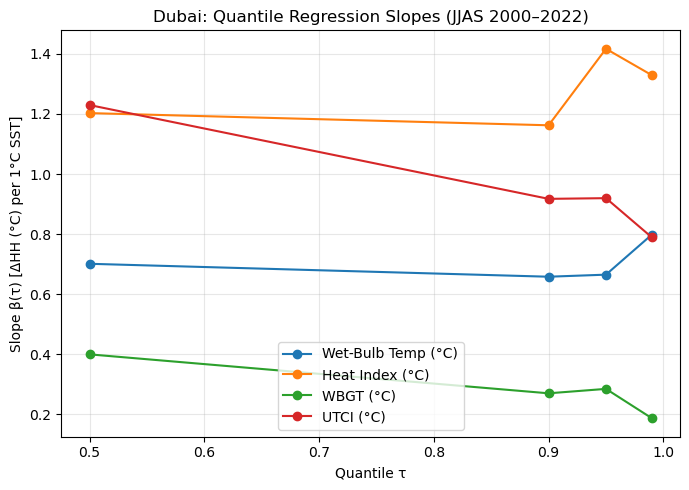

In [2]:
# ------------------ City Coordinates ------------------
CITIES = {
    "Dubai":       (25.2048, 55.2708),
    "Doha":        (25.2854, 51.5310),
    "Aden":        (12.7855, 45.0187),
    "Muscat":      (23.6150, 58.5453),
    "Jeddah":      (21.4858, 39.1925),
    "Al_Hudaydah": (14.7978, 42.9530),
}

# choose a city here
city_name = "Dubai"
CITY_LAT, CITY_LON = CITIES[city_name]
CITY_RADIUS_KM = 30.0   # land HH metrics
SST_RADIUS_KM  = 50.0   # adjacent SST

YEARS = range(2000, 2023)   # 2000–2022 inclusive
JJAS_MONTHS = [6, 7, 8, 9]

FILL_THRESHOLD = -100.0

QUANTILES = [0.50, 0.90, 0.95, 0.99]
METRICS = [
    ("WBT_C",  "Wet-Bulb Temp (°C)"),
    ("HI_C",   "Heat Index (°C)"),
    ("WBGT_C", "WBGT (°C)"),
    ("UTCI_C", "UTCI (°C)"),
]

# ---------------- helpers ----------------
def clean_temp_c(da):
    da = da.where(da > FILL_THRESHOLD)
    da.attrs["units"] = "degC"
    return da

def clean_wbt(da):
    """Clean WBT specifically: mask bogus low values and enforce WBT >= 0°C."""
    da = da.where(da > FILL_THRESHOLD)
    da = da.where(da >= 0)
    da.attrs["units"] = "degC"
    return da

def clean_temp_k_to_c(da):
    da_c = da - 273.15
    da_c.attrs["units"] = "degC"
    da_c = da_c.where(da_c > FILL_THRESHOLD)
    return da_c

def haversine_distance_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def city_mean_series(da, city_lat, city_lon, radius_km):
    """
    Given a DataArray da(time, lat, lon), return a 1D time series
    of the mean over all grid cells within radius_km of (city_lat, city_lon).
    """
    lat2d, lon2d = xr.broadcast(da["lat"], da["lon"])  # dims (lat, lon)
    dist = haversine_distance_km(lat2d, lon2d, city_lat, city_lon)
    mask = dist <= radius_km
    da_city = da.where(mask)
    return da_city.mean(dim=("lat", "lon"), skipna=True)

# ---------------- yearly open functions ----------------
def open_wbt_year(year):
    fn = PATH_WBT / f"DailyMax-WBT-{year}.nc"
    ds = xr.open_dataset(fn, chunks='auto')
    da = ds["twx"]  # (time, latitude, longitude), global
    da = da.sel(
        longitude=slice(30.0, 65.0),
        latitude=slice(40.0, 5.0),   # descending latitude
    )
    da = da.rename(latitude="lat", longitude="lon")
    da = clean_wbt(da)
    return da

def open_hi_year(year):
    fn = PATH_HI / f"hi_AP_{year}.nc"
    ds = xr.open_dataset(fn, chunks='auto')
    da = ds["hi"]  # (time, y, x)
    da = da.rename(y="lat", x="lon")
    da = clean_temp_c(da)
    return da

def open_wbgt_year(year):
    fn = PATH_WBGT / f"wbgt_AP_{year}.nc"
    ds = xr.open_dataset(fn, chunks='auto')
    da = ds["wbgt"]  # (time, y, x)
    da = da.rename(y="lat", x="lon")
    da = clean_temp_c(da)
    return da

def open_utci_year(year):
    files = sorted(PATH_UTCI.glob(f"era5heat_utci_max_{year}_*.nc"))
    if not files:
        raise FileNotFoundError(f"No UTCI files for year {year}")
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds["utci_max"]  # (time, lat, lon), K
    da = clean_temp_k_to_c(da)
    return da

def open_sst_year(year):
    files = sorted(PATH_SST.glob(f"era5_sst_daily_mean_ap_{year}_*.nc"))
    if not files:
        raise FileNotFoundError(f"No SST files for year {year}")
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds["sst"]  # (valid_time, latitude, longitude), K
    da = da.rename(valid_time="time", latitude="lat", longitude="lon")
    da = clean_temp_k_to_c(da)
    return da

# ---------------- build city DataFrame (JJAS 2000–2022) ----------------
def build_city_df(city_name, city_lat, city_lon):
    records = []

    for year in YEARS:
        print(f"[{city_name}] Processing {year}...")
        wbt_y  = open_wbt_year(year)
        hi_y   = open_hi_year(year)
        wbgt_y = open_wbgt_year(year)
        utci_y = open_utci_year(year)
        sst_y  = open_sst_year(year)

        # JJAS slice
        wbt_j  = wbt_y.sel(time=wbt_y.time.dt.month.isin(JJAS_MONTHS))
        hi_j   = hi_y.sel(time=hi_y.time.dt.month.isin(JJAS_MONTHS))
        wbgt_j = wbgt_y.sel(time=wbgt_y.time.dt.month.isin(JJAS_MONTHS))
        utci_j = utci_y.sel(time=utci_y.time.dt.month.isin(JJAS_MONTHS))
        sst_j  = sst_y.sel(time=sst_y.time.dt.month.isin(JJAS_MONTHS))

        # common times
        times_common = (
            pd.Index(wbt_j.time.values)
            .intersection(hi_j.time.values)
            .intersection(wbgt_j.time.values)
            .intersection(utci_j.time.values)
            .intersection(sst_j.time.values)
        )
        times_common = times_common.sort_values()

        if len(times_common) == 0:
            print(f"  -> No overlapping JJAS days in {year}, skipping.")
            continue

        wbt_j  = wbt_j.sel(time=times_common)
        hi_j   = hi_j.sel(time=times_common)
        wbgt_j = wbgt_j.sel(time=times_common)
        utci_j = utci_j.sel(time=times_common)
        sst_j  = sst_j.sel(time=times_common)

        # city & SST neighborhood means
        wbt_city  = city_mean_series(wbt_j,  city_lat, city_lon, CITY_RADIUS_KM)
        hi_city   = city_mean_series(hi_j,   city_lat, city_lon, CITY_RADIUS_KM)
        wbgt_city = city_mean_series(wbgt_j, city_lat, city_lon, CITY_RADIUS_KM)
        utci_city = city_mean_series(utci_j, city_lat, city_lon, CITY_RADIUS_KM)
        sst_city  = city_mean_series(sst_j,  city_lat, city_lon, SST_RADIUS_KM)

        df_year = pd.DataFrame({
            "time":   times_common,
            "year":   year,
            "SST_C":  sst_city.values,
            "WBT_C":  wbt_city.values,
            "HI_C":   hi_city.values,
            "WBGT_C": wbgt_city.values,
            "UTCI_C": utci_city.values,
        })

        # drop days with non-physical WBT
        df_year = df_year[df_year["WBT_C"] >= 0]

        records.append(df_year)

    df = pd.concat(records, ignore_index=True)
    # drop any rows with missing values in key fields
    df = df.dropna(subset=["SST_C", "WBT_C", "HI_C", "WBGT_C", "UTCI_C"])
    return df

df_city = build_city_df(city_name, CITY_LAT, CITY_LON)
print(f"\n{city_name} JJAS 2000–2022 data shape:", df_city.shape)
print(df_city.describe())

# ---------------- quantile regression ----------------
def quantile_regression_table(df, x_col, y_col, quantiles):
    X = sm.add_constant(df[x_col].values)
    results = []

    for q in quantiles:
        mod = sm.QuantReg(df[y_col].values, X)
        res = mod.fit(q=q)
        intercept = res.params[0]
        slope = res.params[1]
        results.append({
            "metric": y_col,
            "quantile": q,
            "intercept": intercept,
            "slope": slope,
        })

    return pd.DataFrame(results)

all_results = []

for col, label in METRICS:
    tbl = quantile_regression_table(df_city, "SST_C", col, QUANTILES)
    tbl["label"] = label
    all_results.append(tbl)

qr_results = pd.concat(all_results, ignore_index=True)
print("\nQuantile regression results (SST_C → metric):")
print(qr_results)

# ---------------- plot: slope vs quantile for each metric ----------------
fig, ax = plt.subplots(figsize=(7, 5))

for col, label in METRICS:
    sub = qr_results[qr_results["metric"] == col]
    ax.plot(sub["quantile"], sub["slope"], marker="o", label=label)

ax.set_xlabel("Quantile τ")
ax.set_ylabel("Slope β(τ) [ΔHH (°C) per 1°C SST]")
ax.set_title(f"{city_name}: Quantile Regression Slopes (JJAS 2000–2022)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


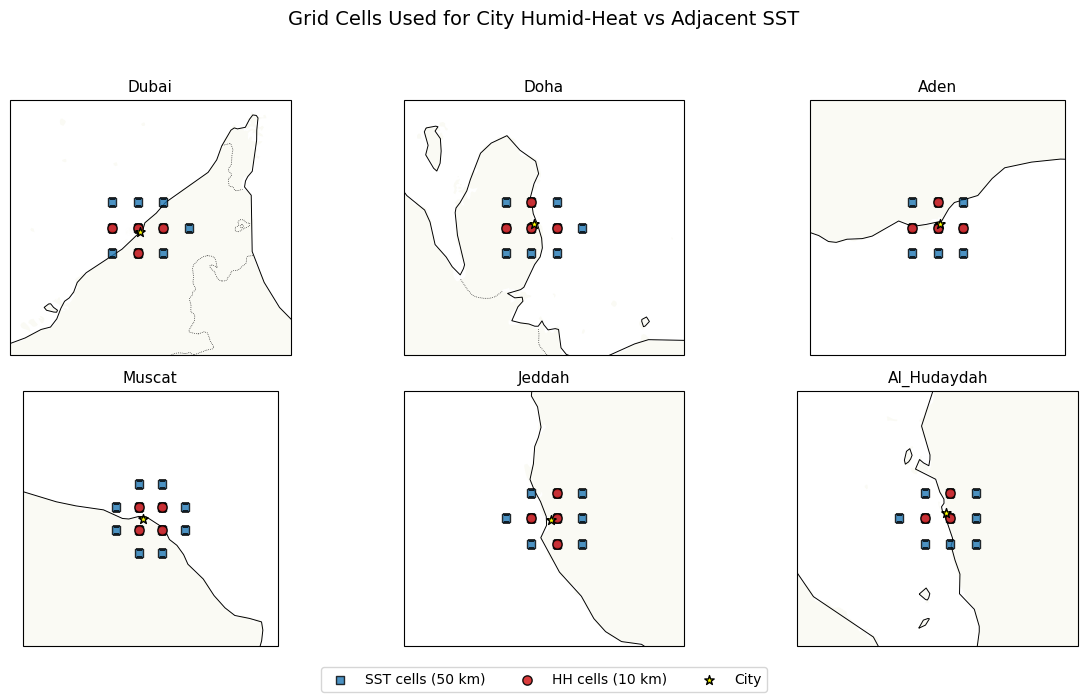

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# If not already defined in the notebook:
# CITY_RADIUS_KM = 10.0
# SST_RADIUS_KM  = 50.0

def get_hh_sst_masks_for_city(city_lat, city_lon, ref_year=2000):
    """
    Build boolean masks for humid-heat (WBT grid) and SST (SST grid)
    around a city for visualization purposes.
    """
    # ---- Humid-heat grid: use WBT grid as representative (0.25°) ----
    wbt_y = open_wbt_year(ref_year)     # (time, lat, lon), °C
    hh = wbt_y.isel(time=0)            # we only need coords

    lat2d_hh, lon2d_hh = xr.broadcast(hh["lat"], hh["lon"])
    dist_hh = haversine_distance_km(lat2d_hh, lon2d_hh, city_lat, city_lon)
    hh_mask = dist_hh <= CITY_RADIUS_KM   # boolean (lat, lon)

    # ---- SST grid ----
    sst_y = open_sst_year(ref_year)   # (time, lat, lon), °C
    sst0 = sst_y.isel(time=0)

    lat2d_sst, lon2d_sst = xr.broadcast(sst0["lat"], sst0["lon"])
    dist_sst = haversine_distance_km(lat2d_sst, lon2d_sst, city_lat, city_lon)
    sst_mask = dist_sst <= SST_RADIUS_KM

    return (hh["lat"], hh["lon"], hh_mask), (sst0["lat"], sst0["lon"], sst_mask)


# ------------ Plot for all cities: HH cells vs SST cells ------------
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(12, 7),
    subplot_kw=dict(projection=proj),
)

axes = axes.ravel()
city_list = list(CITIES.items())

for ax, (city_name, (clat, clon)) in zip(axes, city_list):
    # get masks
    (lat_hh, lon_hh, hh_mask), (lat_sst, lon_sst, sst_mask) = get_hh_sst_masks_for_city(
        clat, clon
    )
    
    # HH grid points: broadcast in (lat, lon) order to match hh_mask
    lat2d_hh, lon2d_hh = xr.broadcast(lat_hh, lon_hh)
    hh_lon_pts = lon2d_hh.values[hh_mask.values]
    hh_lat_pts = lat2d_hh.values[hh_mask.values]
    
    # SST grid points: same idea, (lat, lon) order to match sst_mask
    lat2d_sst, lon2d_sst = xr.broadcast(lat_sst, lon_sst)
    sst_lon_pts = lon2d_sst.values[sst_mask.values]
    sst_lat_pts = lat2d_sst.values[sst_mask.values]

    
    
    # background
    ax.coastlines(resolution="50m", linewidth=0.7)
    ax.add_feature(cfeature.LAND, alpha=0.3, zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=0)

    # plot SST neighborhood (larger radius)
    ax.scatter(
        sst_lon_pts, sst_lat_pts,
        transform=proj,
        s=35,
        marker="s",
        edgecolor="k",
        facecolor="tab:blue",
        label="SST cells (50 km)",
        zorder=2,
        alpha=0.8,
    )

    # plot HH neighborhood (smaller radius; overlay)
    ax.scatter(
        hh_lon_pts, hh_lat_pts,
        transform=proj,
        s=45,
        marker="o",
        edgecolor="k",
        facecolor="tab:red",
        label="HH cells (10 km)",
        zorder=3,
        alpha=0.9,
    )

    # city marker
    ax.scatter(
        [clon], [clat],
        transform=proj,
        s=50,
        marker="*",
        edgecolor="k",
        facecolor="yellow",
        zorder=4,
        label="City",
    )

    # nice zoomed extent around city
    lon_min = min(hh_lon_pts.min(), sst_lon_pts.min(), clon) - 1.0
    lon_max = max(hh_lon_pts.max(), sst_lon_pts.max(), clon) + 1.0
    lat_min = min(hh_lat_pts.min(), sst_lat_pts.min(), clat) - 1.0
    lat_max = max(hh_lat_pts.max(), sst_lat_pts.max(), clat) + 1.0
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.set_title(city_name, fontsize=11)

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=True,
)

fig.suptitle("Grid Cells Used for City Humid-Heat vs Adjacent SST", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [11]:
(hh_lat, hh_lon, hh_mask), (sst_lat, sst_lon, sst_mask) = get_hh_sst_masks_for_city(
    clat, clon
)

print(
    f"{city_name}: HH cells = {hh_mask.values.sum()}, "
    f"SST cells = {sst_mask.values.sum()}"
)

Muscat: HH cells = 0, SST cells = 12
